In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import pycountry_convert as pc
import plotly.express as px
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")

In [35]:
RANDOM_SEED = 42

## Load datasets

In [36]:
transactions_df = pd.read_csv("../data/raw/transactions_data.csv", parse_dates=["date"])
target_labels_df = pd.read_json("../data/raw/train_fraud_labels.json")

In [37]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   client_id       int64         
 3   card_id         int64         
 4   amount          object        
 5   use_chip        object        
 6   merchant_id     int64         
 7   merchant_city   object        
 8   merchant_state  object        
 9   zip             float64       
 10  mcc             int64         
 11  errors          object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 1.2+ GB


### Initial preprocessing

In [38]:
transactions_df = transactions_df.astype({n:str(transactions_df[n].dtype).replace("64", "32") for n in transactions_df.select_dtypes(include=["int64", "float64"]).columns})

In [39]:
transactions_df["amount"] = transactions_df["amount"].str.replace("$","").astype(float)

In [40]:
print("Shape Transactions:",transactions_df.shape)
print("Columns Transactions:",transactions_df.columns)
print("Shape Labels:",target_labels_df.shape)
print("Columns Labels:",target_labels_df.columns)

Shape Transactions: (13305915, 12)
Columns Transactions: Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')
Shape Labels: (8914963, 1)
Columns Labels: Index(['target'], dtype='object')


## Merge with target labels

In [41]:
with_labels = transactions_df[transactions_df.id.isin(target_labels_df.index)]
no_labels = transactions_df[~(transactions_df.id.isin(target_labels_df.index))]
print("With labels:", with_labels.shape)
print("No labels:", no_labels.shape)

With labels: (8914963, 12)
No labels: (4390952, 12)


No labels records are intended for the submission file (test)

In [42]:
no_labels.to_csv("../data/raw/test_transactions.csv")

In [43]:
# the rest will be 
print("Transactions wit labels before merging",len(with_labels["id"].unique()))
transactions_df = with_labels.merge(target_labels_df.reset_index().rename(columns={"index":"id", "target":"target"}), on="id")
print("Transactions after merging",len(transactions_df["id"].unique()))



Transactions wit labels before merging 8914963
Transactions after merging 8914963


## Split on train/test sets

We will create train test splits based on the temporal data to simulate production scenario

In [44]:
transactions_df["date"].agg(["max", "min"])

max   2019-10-31 23:57:00
min   2010-01-01 00:01:00
Name: date, dtype: datetime64[ns]

In [45]:
split_date = '2018-01-01'

train = transactions_df[transactions_df['date'] < split_date]
test = transactions_df[transactions_df['date'] >= split_date]

print(train['date'].max(), test['date'].min())
print(train.shape, test.shape)
print(train['target'].value_counts(normalize=True))
print(test['target'].value_counts(normalize=True))

2017-12-31 23:59:00 2018-01-01 00:05:00
(7203025, 13) (1711938, 13)
target
No     0.998564
Yes    0.001436
Name: proportion, dtype: float64
target
No     0.998254
Yes    0.001746
Name: proportion, dtype: float64


In [46]:
train.to_csv("../data/processed/transactions_train.csv", index=False)
test.to_csv("../data/processed/transactions_test.csv", index=False)

In [47]:
transactions_df = pd.read_csv("../data/processed/transactions_train.csv")

## Explore Nan records

In [48]:
nan_records=transactions_df.isna().sum()
fraction = nan_records/transactions_df.shape[0]
pd.concat([nan_records, fraction], axis = 1).rename({"0":"Number of records", "1":"Fraction of total"})

,0,1
id,0,0.000000
date,0,0.000000
client_id,0,0.000000
card_id,0,0.000000
amount,0,0.000000
use_chip,0,0.000000
merchant_id,0,0.000000
merchant_city,0,0.000000
merchant_state,839458,0.116542
zip,885601,0.122948


In [49]:
records_with_empty_state = transactions_df[transactions_df.merchant_state.isna()]
records_with_empty_zip = transactions_df[transactions_df.zip.isna()]
records_with_empty_errors = transactions_df[transactions_df.errors.isna()]

<Axes: title={'center': 'Errors'}, xlabel='target', ylabel='count'>

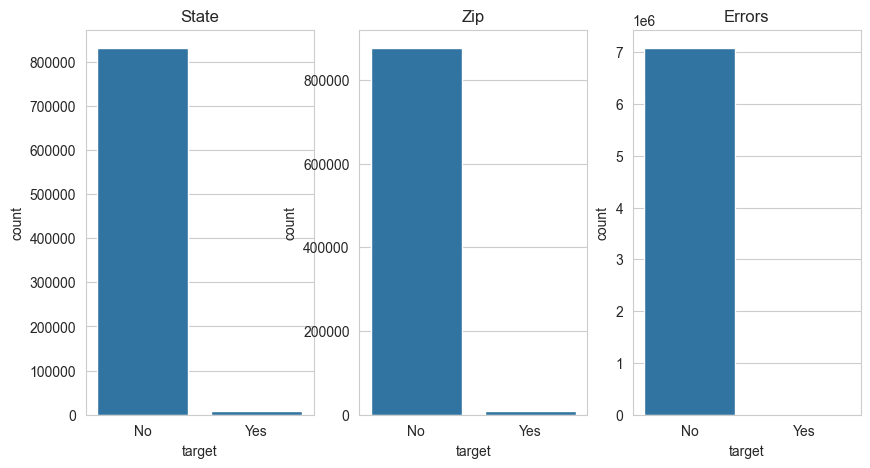

In [50]:
# target distribution
fig, axes = plt.subplots(1,3, figsize=(10,5))
axes[0].set_title("State")
sns.countplot(data=records_with_empty_state, x = "target", ax=axes[0])
axes[1].set_title("Zip")
sns.countplot(data=records_with_empty_zip, x = "target", ax=axes[1])
axes[2].set_title("Errors")
sns.countplot(data=records_with_empty_errors, x = "target", ax=axes[2])


In [51]:
city_count_state_nan = records_with_empty_state.merchant_city.value_counts().rename("State Nan")
city_count_zip_nan = records_with_empty_zip.merchant_city.value_counts().rename("Zip Nan")
all_cities = transactions_df["merchant_city"].value_counts().rename("Total")
pd.concat([all_cities, city_count_state_nan, city_count_zip_nan], axis = 1).dropna(axis=0, subset=["State Nan", "Zip Nan"], how="all")

,Total,State Nan,Zip Nan
merchant_city,,,
ONLINE,839458,839458.0,839458.0
San Jose,16436,NaN,343.0
Vancouver,8487,NaN,1080.0
Panama City,6927,NaN,5.0
Warsaw,5905,NaN,97.0
...,...,...,...
Libreville,2,NaN,2.0
Paramaribo,2,NaN,2.0
Malabo,2,NaN,2.0


Missing city -> Online purchase

In [52]:
transactions_df[~(transactions_df["errors"].isna())]["errors"].value_counts()

errors
Insufficient Balance                                   70969
Bad PIN                                                17369
Technical Glitch                                       14309
Bad Card Number                                         4201
Bad CVV                                                 3300
Bad Expiration                                          3298
Bad Zipcode                                              629
Bad PIN,Insufficient Balance                             152
Insufficient Balance,Technical Glitch                    129
Bad Card Number,Insufficient Balance                      41
Bad CVV,Insufficient Balance                              33
Bad PIN,Technical Glitch                                  33
Bad Expiration,Insufficient Balance                       28
Bad Card Number,Bad Expiration                            25
Bad Card Number,Bad CVV                                   20
Bad Expiration,Bad CVV                                    15
Bad Card Number,T

Error imputation -> No error

In [53]:
transactions_df[transactions_df["merchant_city"]=="Rome"]["zip"].value_counts()

zip
13440.0    447
30165.0     77
30161.0     29
30162.0      2
18837.0      2
30164.0      1
Name: count, dtype: int64

Missing Zip -> Mode of the city

## Explore invalid values

In [54]:
obj_cols = transactions_df.select_dtypes(include=["object"]).columns
numeric_cols = [n for n in transactions_df.columns if n not in obj_cols]
print("Object cols:", obj_cols)
print("Numeric cols:", numeric_cols)

Object cols: Index(['date', 'use_chip', 'merchant_city', 'merchant_state', 'errors',
       'target'],
      dtype='object')
Numeric cols: ['id', 'client_id', 'card_id', 'amount', 'merchant_id', 'zip', 'mcc']


### Check numeric

In [55]:
# check min/max values
transactions_df[numeric_cols].agg(["min", "max"])

,id,client_id,card_id,amount,merchant_id,zip,mcc
min,7475327,0,0,-500.00,1,1001.0,1711
max,20604846,1998,6134,5696.78,100342,99928.0,9402


In [56]:
print(transactions_df[transactions_df["amount"]<0].shape)

negative_amount = transactions_df[transactions_df["amount"]<0]
for n in obj_cols:
    print(negative_amount[n].value_counts(normalize=True))

(359104, 13)
date
2014-06-26 13:10:00    0.000014
2015-09-05 07:04:00    0.000014
2017-01-05 06:32:00    0.000011
2017-06-27 07:03:00    0.000011
2014-01-05 16:23:00    0.000011
                         ...   
2012-10-26 13:36:00    0.000003
2012-10-26 13:23:00    0.000003
2012-10-26 13:16:00    0.000003
2012-10-26 13:14:00    0.000003
2017-12-31 23:59:00    0.000003
Name: proportion, Length: 337847, dtype: float64
use_chip
Swipe Transaction     0.681839
Chip Transaction      0.306933
Online Transaction    0.011228
Name: proportion, dtype: float64
merchant_city
Houston       0.016675
ONLINE        0.014550
Olympia       0.012935
Farmington    0.011902
Columbia      0.011484
                ...   
Gas City      0.000003
Cochran       0.000003
Falconer      0.000003
Portal        0.000003
Tujunga       0.000003
Name: proportion, Length: 5915, dtype: float64
merchant_state
CA            0.129437
TX            0.088197
FL            0.061676
NY            0.058034
OH            0.050167
  

Text(0.5, 1.0, 'Fraud/Legit refund')

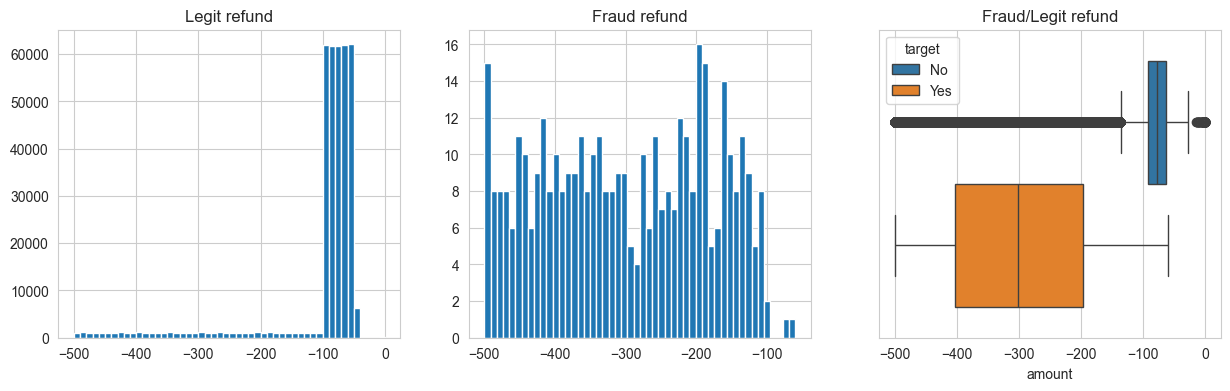

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
negative_amount[negative_amount['target']=='No']['amount'].hist(ax=axes[0], bins=50)
axes[0].set_title('Legit refund')
negative_amount[negative_amount['target']=='Yes']['amount'].hist(ax=axes[1], bins=50)
axes[1].set_title('Fraud refund')
sns.boxplot(data=negative_amount, x = "amount", hue="target", ax=axes[2])
axes[2].set_title('Fraud/Legit refund')

Negative amount is a refund, so we can create a new feature is_refund for amount<0. Median of the fraud refunds is approx 2 times higher, than no negative

### Check categorical

In [58]:
for n in obj_cols:
    print(transactions_df[n].value_counts(normalize=True))

date
2013-01-07 12:53:00    1.943628e-06
2014-12-25 10:40:00    1.804797e-06
2017-06-13 08:03:00    1.804797e-06
2017-07-25 11:13:00    1.804797e-06
2013-04-18 07:35:00    1.804797e-06
                           ...     
2012-07-14 04:47:00    1.388306e-07
2012-07-14 04:50:00    1.388306e-07
2012-07-14 04:53:00    1.388306e-07
2012-07-14 04:54:00    1.388306e-07
2010-01-01 00:01:00    1.388306e-07
Name: proportion, Length: 2987131, dtype: float64
use_chip
Swipe Transaction     0.607892
Chip Transaction      0.275900
Online Transaction    0.116208
Name: proportion, dtype: float64
merchant_city
ONLINE             1.165424e-01
Houston            1.113143e-02
Miami              6.658730e-03
Brooklyn           6.293745e-03
Los Angeles        6.220026e-03
                       ...     
Depauw             1.388306e-07
Fort Montgomery    1.388306e-07
Looneyville        1.388306e-07
Speonk             1.388306e-07
Meadview           1.388306e-07
Name: proportion, Length: 11798, dtype: float64


For the categorical we will introduce "Other" category for the minor cases

## Explore target variable

In [59]:
total_target = transactions_df["target"].value_counts()
target_normalized = transactions_df["target"].value_counts(normalize=True)
pd.concat([total_target, target_normalized], axis=1)

,count,proportion
target,,
No,7192682,0.998564
Yes,10343,0.001436


### Amount vs Target

In [60]:
transactions_df.groupby("target")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
No,7192682.0,42.912455,81.261086,-500.0,8.930,28.99,63.740,5696.78
Yes,10343.0,118.235445,227.911519,-500.0,25.995,79.87,158.295,4978.45


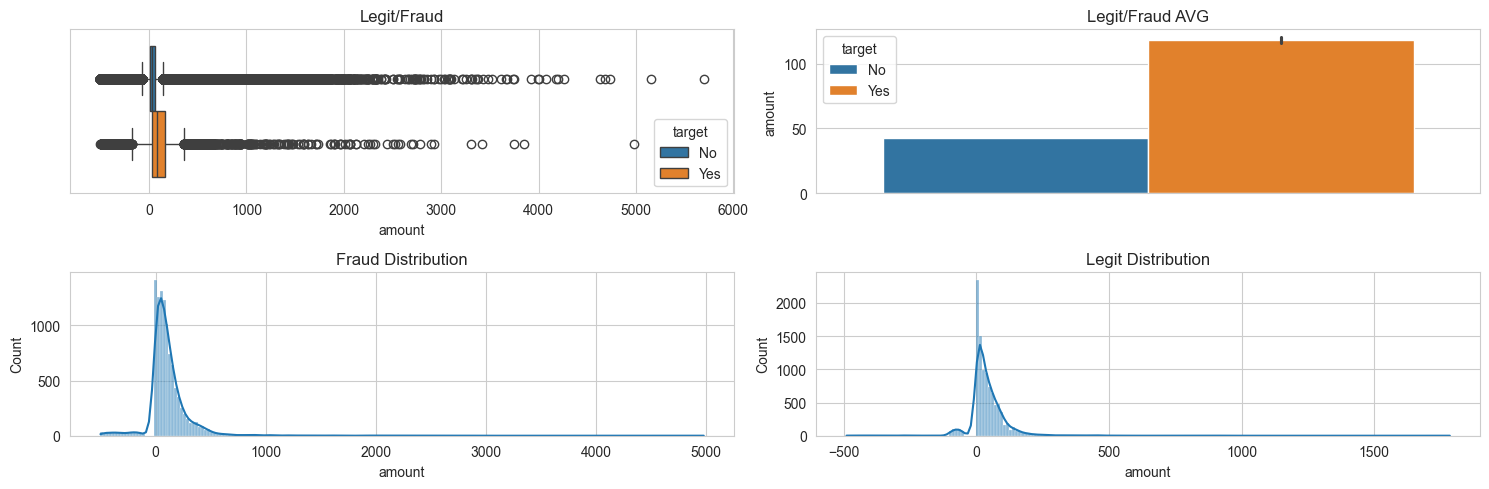

In [61]:
# amount vs target
fig, axes = plt.subplots(2,2, figsize=(15,5))
axes[0,0].set_title("Legit/Fraud")
sns.boxplot(data=transactions_df, x="amount", hue="target", ax=axes[0,0])
axes[0,1].set_title("Legit/Fraud AVG")
sns.barplot(data=transactions_df, hue = "target", y="amount", errorbar="se", ax=axes[0,1])
axes[1,0].set_title("Fraud Distribution")
sns.histplot(data=transactions_df[transactions_df["target"]=="Yes"], x="amount", kde=True, ax=axes[1,0])
axes[1,1].set_title("Legit Distribution")
sns.histplot(data=transactions_df[transactions_df["target"]=="No"].sample(10000, random_state=RANDOM_SEED),  x="amount", kde=True, ax=axes[1,1])
plt.tight_layout()
plt.show()

* Avg amount of the positive group is higher, than negative with no overlapping standard errors
* Both distributions are right skewed 
* Fraud max amount is near 5k and legit near 6k

### Datetime vs target

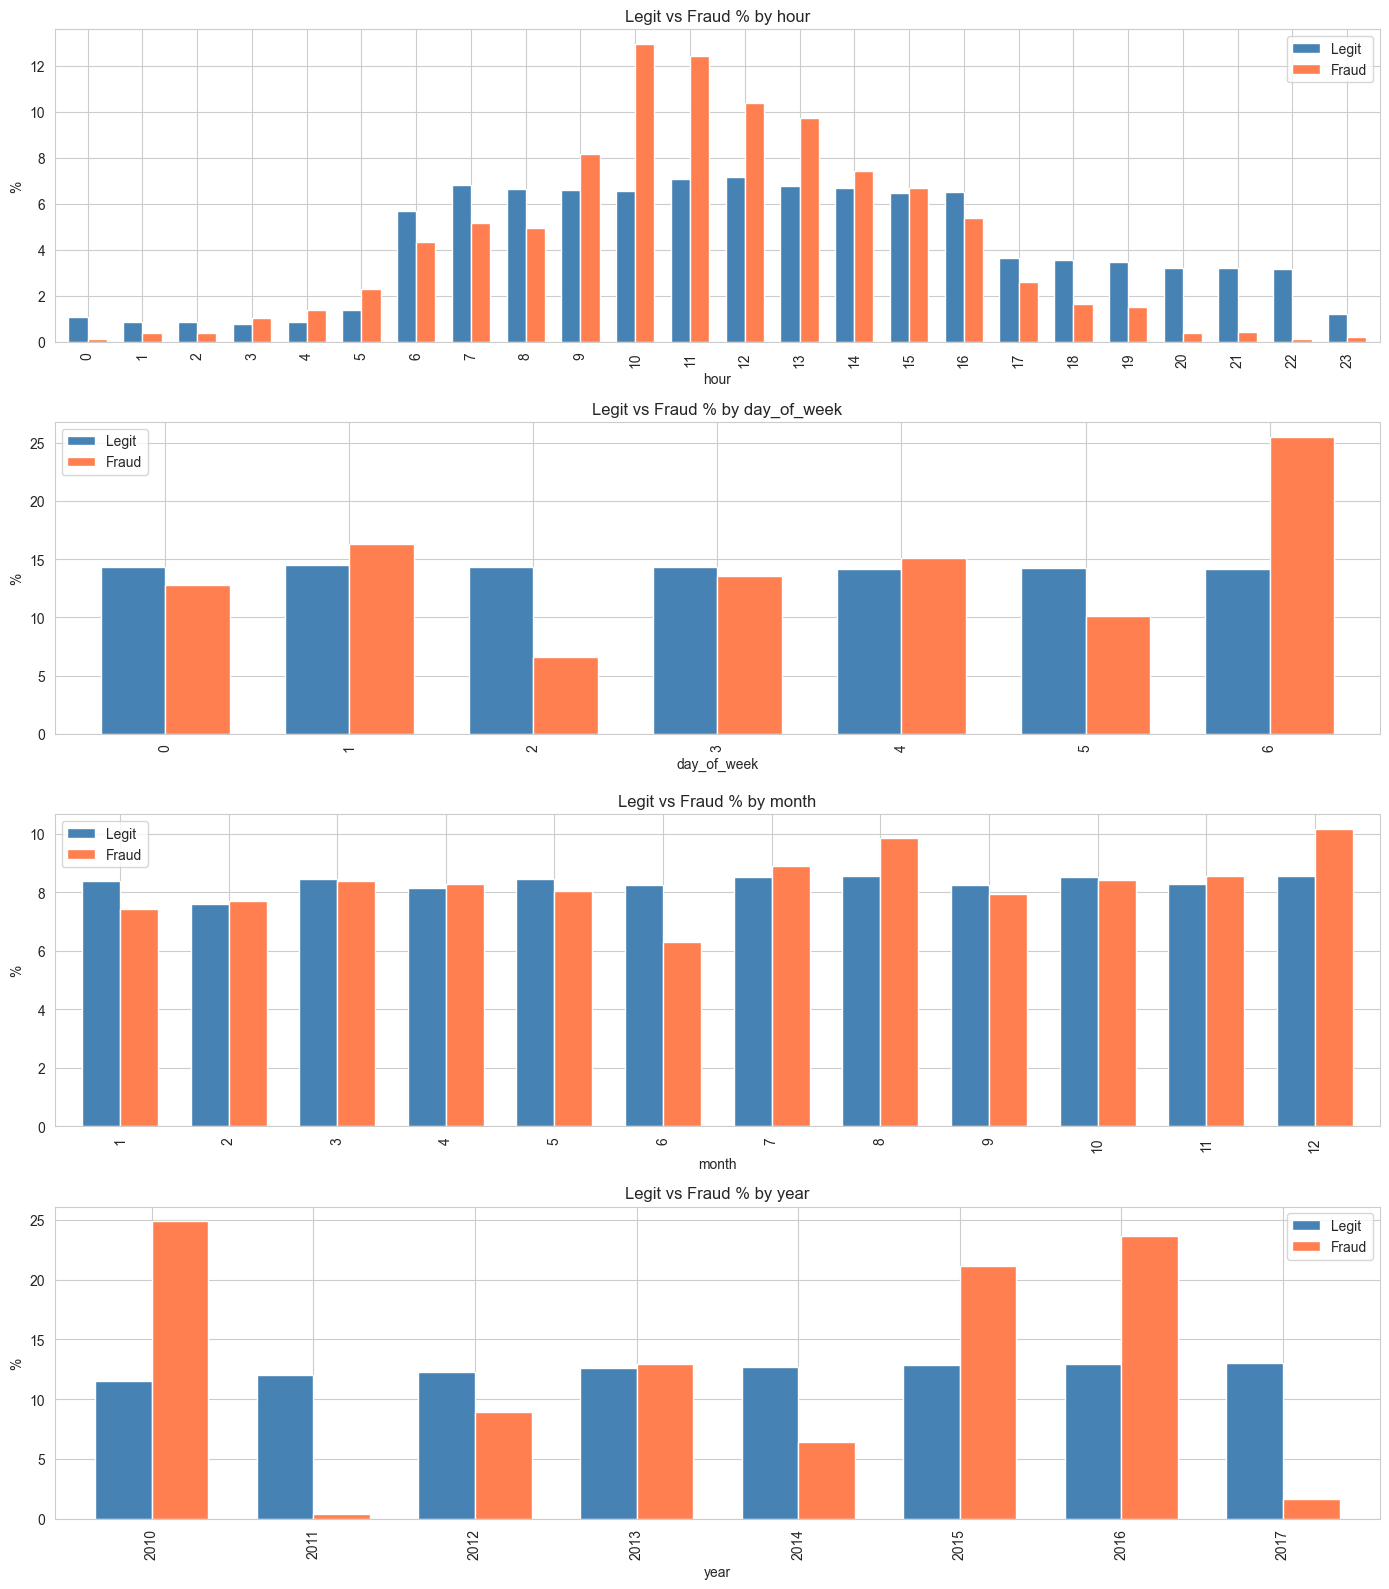

In [62]:
transactions_df['date'] = pd.to_datetime(transactions_df['date'])
transactions_df['hour'] = transactions_df['date'].dt.hour
transactions_df['day_of_week'] = transactions_df['date'].dt.dayofweek
transactions_df['month'] = transactions_df['date'].dt.month
transactions_df['year'] = transactions_df['date'].dt.year


fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, col in enumerate(['hour', 'day_of_week', 'month', 'year']):
    fraud = transactions_df[transactions_df['target']=='Yes'].groupby(col).size()
    legit = transactions_df[transactions_df['target']=='No'].groupby(col).size()
    
    fraud_pct = fraud / fraud.sum() * 100
    legit_pct = legit / legit.sum() * 100

    pd.DataFrame({'Legit': legit_pct, 'Fraud': fraud_pct}).plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'], width=0.7)
    axes[i].set_title(f'Legit vs Fraud % by {col}')
    axes[i].set_ylabel('%')

plt.tight_layout()
plt.show()

* Most of the fraud transactions happen during the day so we can create feature 'is_midday' (between 10 and 16) or maybe just add 'hour' feature

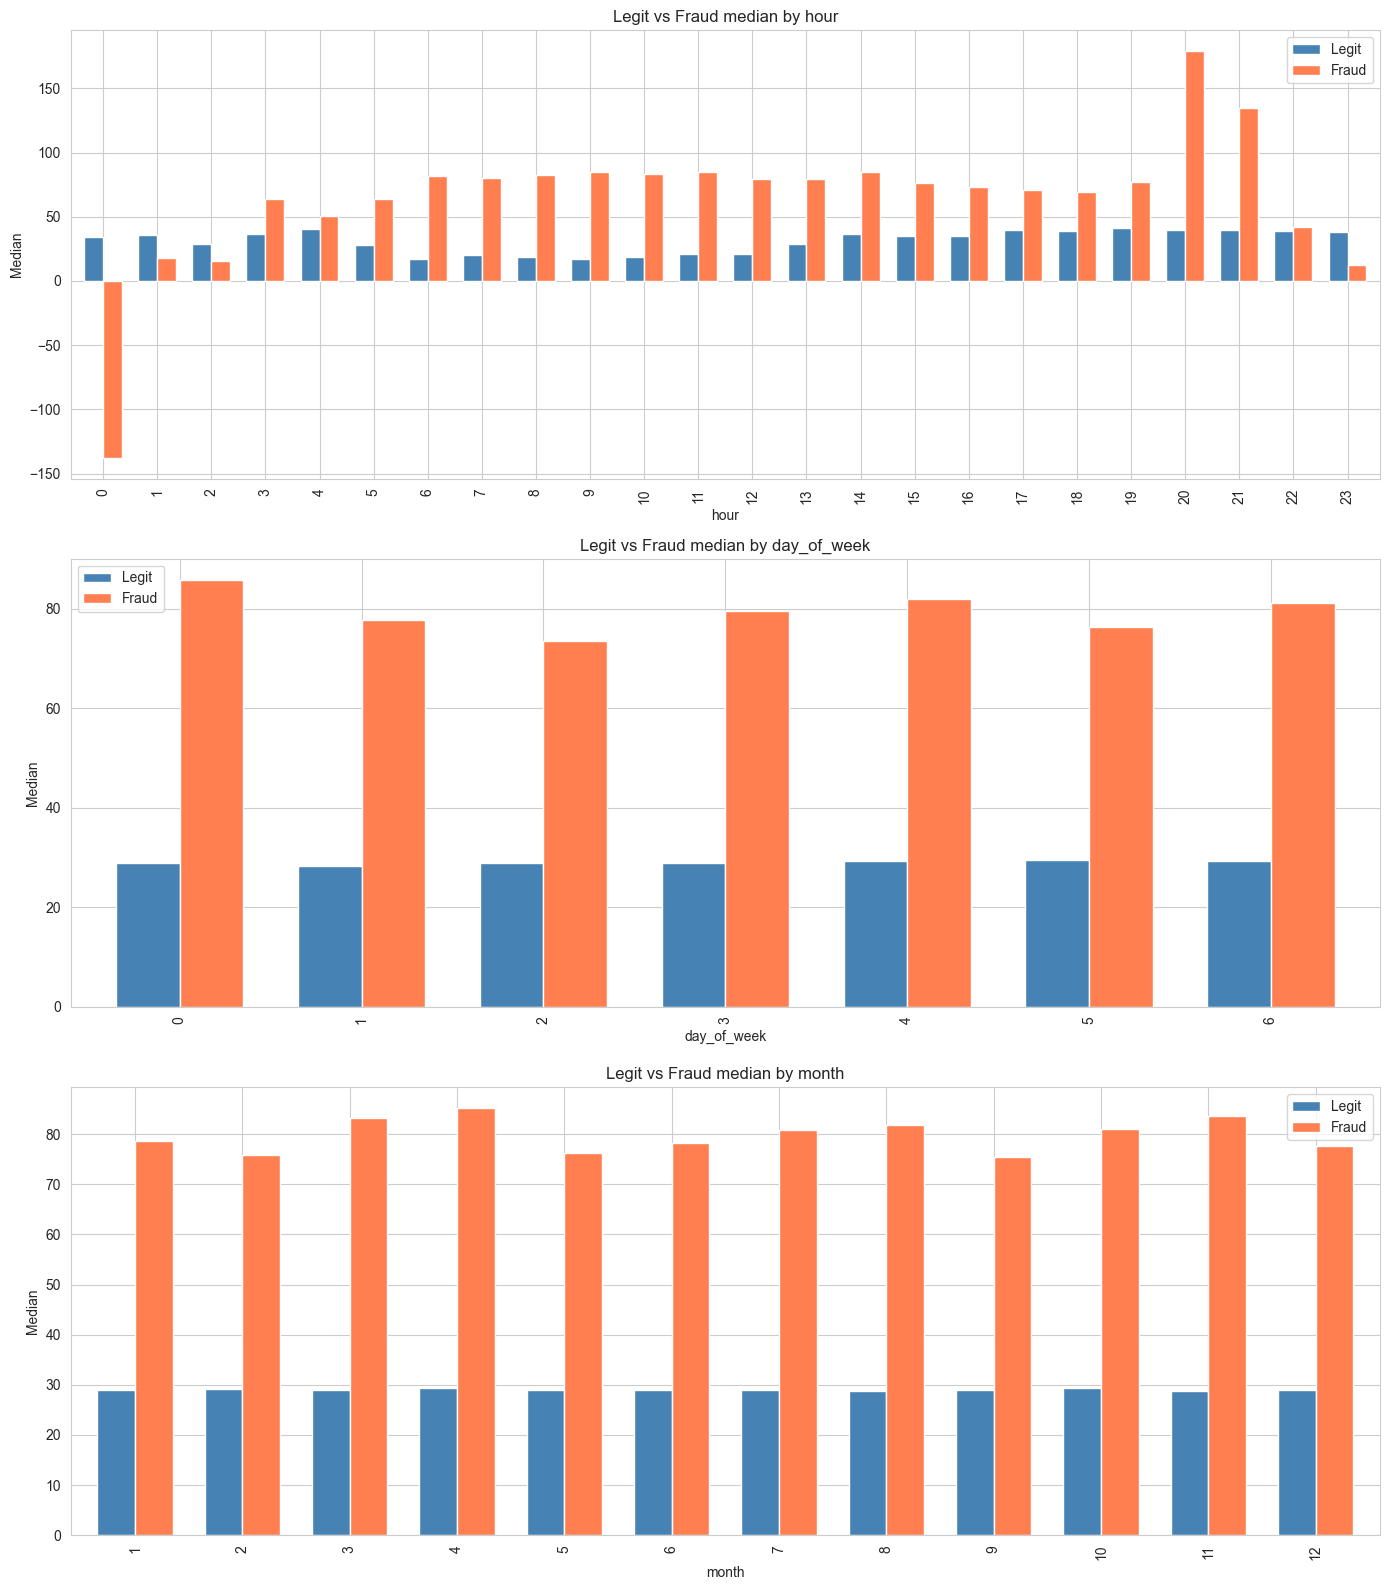

In [63]:

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for i, col in enumerate(['hour', 'day_of_week', 'month']):
    fraud = transactions_df[transactions_df['target']=='Yes'].groupby(col)["amount"].median()
    legit = transactions_df[transactions_df['target']=='No'].groupby(col)["amount"].median()

    pd.DataFrame({'Legit': legit, 'Fraud': fraud}).plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'], width=0.7)
    axes[i].set_title(f'Legit vs Fraud median by {col}')
    axes[i].set_ylabel('Median')

plt.tight_layout()
plt.show()

* Median of the fraud is nominally higher, and we have strange pattern at 12am

In [64]:
transactions_df[(transactions_df["hour"]==0) & (transactions_df["amount"]<0) & (transactions_df["target"]=="Yes")].describe()

,id,date,client_id,card_id,amount,merchant_id,zip,mcc,hour,day_of_week,month,year
count,7.000000e+00,7,7.000000,7.000000,7.000000,7.000000,0.0,7.000000,7.0,7.000000,7.000000,7.000000
mean,8.841428e+06,2010-11-20 14:11:08.571428608,1444.428571,3850.428571,-221.714286,43643.857143,NaN,3588.285714,0.0,2.571429,4.571429,2010.571429
min,7.604364e+06,2010-02-03 00:01:00,520.000000,2020.000000,-383.000000,3558.000000,NaN,3405.000000,0.0,0.000000,2.000000,2010.000000
25%,7.799913e+06,2010-03-24 00:23:30,1183.000000,3084.500000,-243.500000,26286.000000,NaN,3506.500000,0.0,1.000000,2.500000,2010.000000
50%,7.972087e+06,2010-05-06 00:48:00,1649.000000,3743.000000,-200.000000,49637.000000,NaN,3596.000000,0.0,3.000000,4.000000,2010.000000
75%,8.356908e+06,2010-08-08 00:36:00,1792.000000,4772.500000,-172.000000,62403.000000,NaN,3662.000000,0.0,4.000000,6.500000,2010.000000
max,1.399990e+07,2014-02-14 00:30:00,1992.000000,5476.000000,-138.000000,74934.000000,NaN,3780.000000,0.0,5.000000,8.000000,2014.000000
std,2.293019e+06,NaN,565.544239,1272.772153,82.141573,28264.155736,NaN,126.249375,0.0,1.988060,2.572751,1.511858


* Midnight negative fraud is only 7 cases, insufficient for conclusions

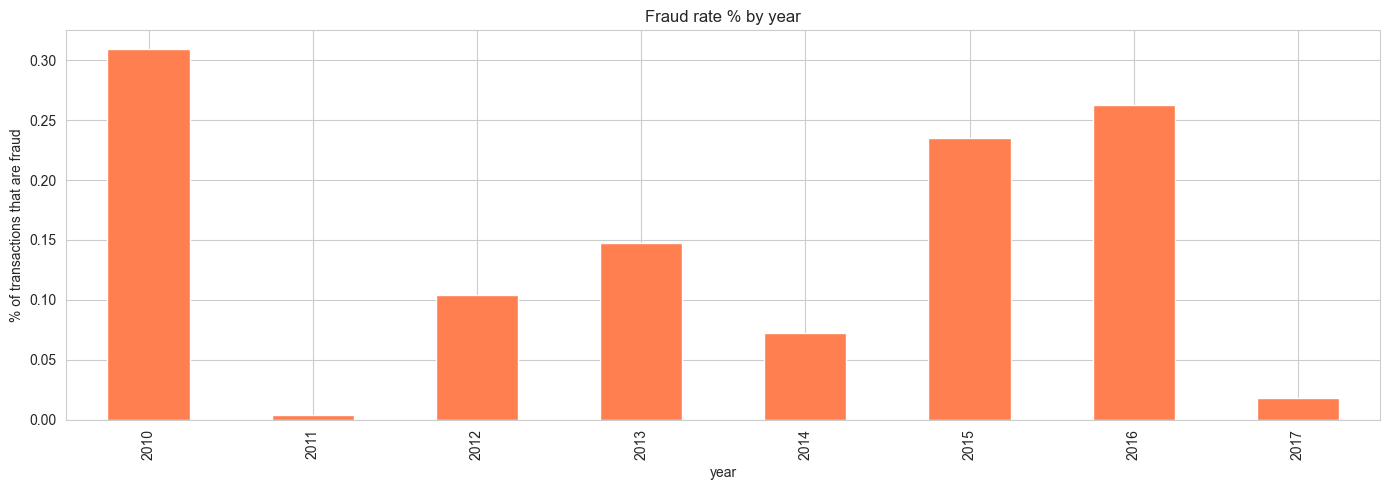

In [85]:
yearly = transactions_df.groupby('year').agg(total=('target', 'count'),fraud=('target', lambda x: (x=='Yes').sum()))
yearly['fraud_rate'] = yearly['fraud'] / yearly['total'] * 100
yearly['fraud_pct_of_all_fraud'] = yearly['fraud'] / yearly['fraud'].sum() * 100

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

yearly['fraud_rate'].plot(kind='bar', ax=axes, color='coral')
axes.set_title('Fraud rate % by year')
axes.set_ylabel('% of transactions that are fraud')

plt.tight_layout()
plt.show()

* exclude year from features

### card_id vs target

In [66]:
count_of_used = transactions_df.groupby("card_id").size().rename("count_of_used")
avg_of_used = transactions_df.groupby("card_id")["amount"].median().rename("median_usage_per_card")
fraud_per_card = transactions_df.groupby("card_id")["target"].apply(lambda x: (x=="Yes").sum()).rename("fraud_per_card")

card_id_info = pd.concat([count_of_used, avg_of_used, fraud_per_card], axis = 1)
card_id_info["fract_fraud"] = card_id_info["fraud_per_card"]/card_id_info["count_of_used"]
card_id_info

,count_of_used,median_usage_per_card,fraud_per_card,fract_fraud
card_id,,,,
0,1829,52.000,0,0.000000
1,1537,47.490,0,0.000000
2,4516,14.935,4,0.000886
3,1674,65.130,0,0.000000
4,475,37.510,3,0.006316
...,...,...,...,...
6129,172,18.995,0,0.000000
6130,293,17.560,0,0.000000
6131,13,25.610,0,0.000000


In [67]:
card_id_info.describe()

,count_of_used,median_usage_per_card,fraud_per_card,fract_fraud
count,3953.000000,3953.000000,3953.000000,3953.000000
mean,1822.166709,32.754184,2.616494,0.002401
std,1589.816126,39.606363,4.201847,0.014966
min,1.000000,0.230000,0.000000,0.000000
25%,799.000000,15.730000,0.000000,0.000000
50%,1433.000000,27.290000,0.000000,0.000000
75%,2322.000000,42.895000,4.000000,0.002186
max,20037.000000,1478.200000,37.000000,0.812500


<Axes: xlabel='fraud_per_card'>

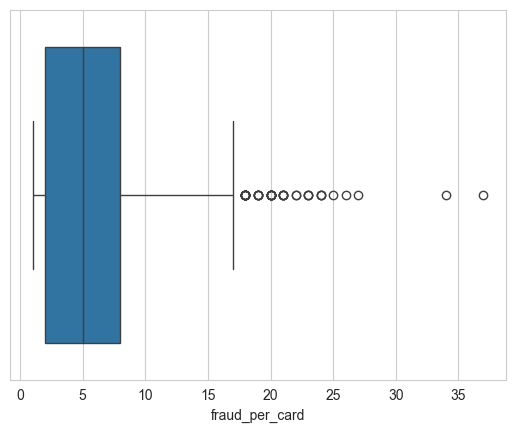

In [68]:
sns.boxplot(data=card_id_info[card_id_info["fraud_per_card"]>0], x= "fraud_per_card")


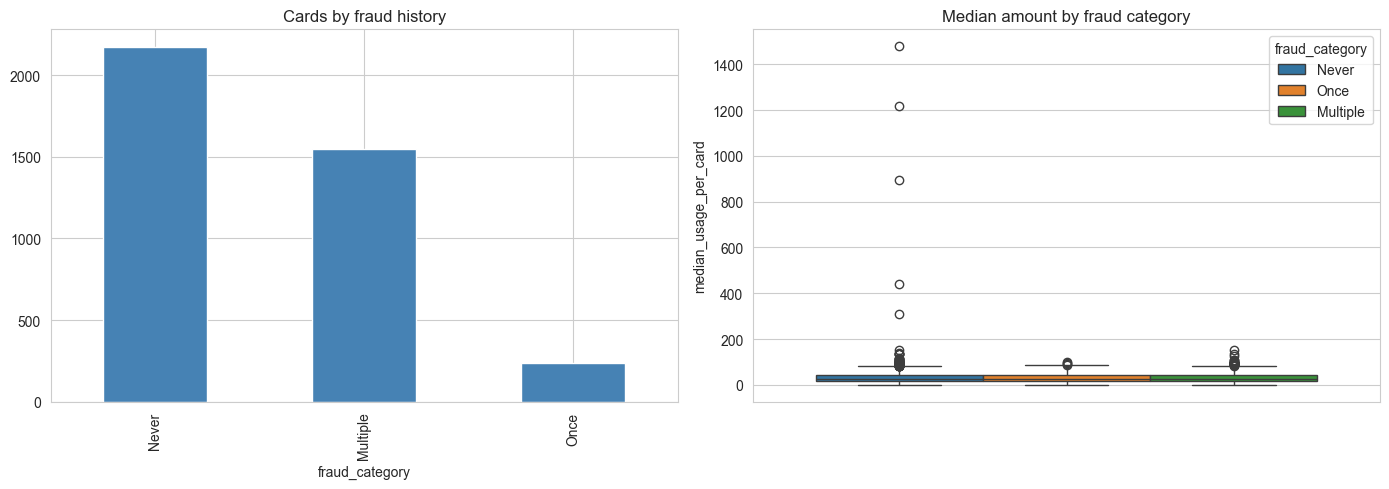

In [69]:
card_id_info['fraud_category'] = pd.cut(card_id_info['fraud_per_card'],bins=[-1, 0, 1, float('inf')],labels=['Never', 'Once', 'Multiple'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

card_id_info['fraud_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cards by fraud history')

sns.boxplot(data=card_id_info, hue='fraud_category', y='median_usage_per_card', ax=axes[1])
axes[1].set_title('Median amount by fraud category')

plt.tight_layout()
plt.show()

In [70]:
total_once = card_id_info[card_id_info['fraud_per_card'] == 1].shape[0]
total_multiple = card_id_info[card_id_info['fraud_per_card'] > 1].shape[0]
total_fraud_cards = total_once + total_multiple

print(f'Once and stopped: {total_once} ({total_once/total_fraud_cards*100}%)')
print(f'Multiple times: {total_multiple} ({total_multiple/total_fraud_cards*100}%)')

Once and stopped: 234 (13.131313131313133%)
Multiple times: 1548 (86.86868686868688%)


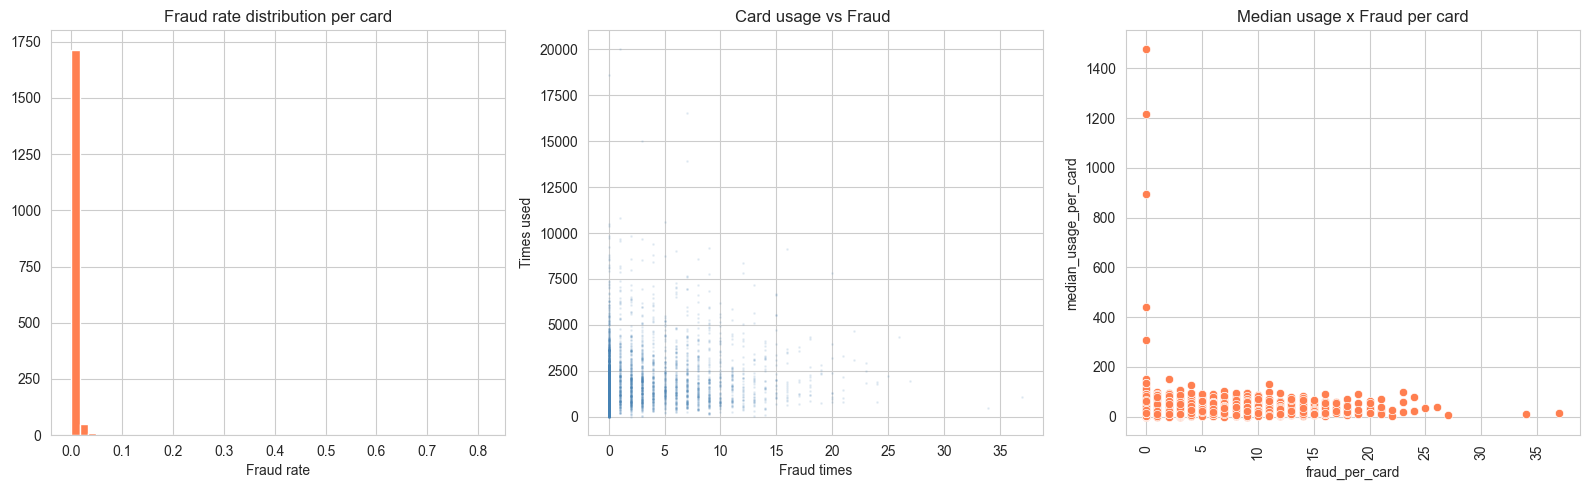

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

card_id_info[card_id_info['fract_fraud']>0]['fract_fraud'].hist(bins=50, ax=axes[0], color='coral')
axes[0].set_title('Fraud rate distribution per card')
axes[0].set_xlabel('Fraud rate')

axes[1].scatter(card_id_info['fraud_per_card'], card_id_info['count_of_used'], alpha=0.1, s=1, color='steelblue')
axes[1].set_title('Card usage vs Fraud ')
axes[1].set_ylabel('Times used')
axes[1].set_xlabel('Fraud times')

sns.scatterplot(data=card_id_info, x='fraud_per_card', y='median_usage_per_card', ax=axes[2], color='coral')
axes[2].set_title('Median usage x Fraud per card')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

* we have one card that was used 14 times and 11 of them a re marked as fraud resulting in ratio 0.7857142857142857 and is a potential oultier
* no difference in median between groups
* if card was marked as fraud once prob of getting fraud again increases
* we can create feature prev_fraud_history to track number of frauds before, but need to be done carefully to prevent data leakage

### client_id vs target

In [72]:
count_of_cards = transactions_df.groupby("client_id")["card_id"].nunique().rename("count_of_cards")
count_of_transactions = transactions_df.groupby("client_id")["id"].nunique().rename("count_of_transactions")
median_per_card = transactions_df.groupby(["client_id", "card_id"])["amount"].median().rename("median_per_card").reset_index().groupby("client_id")["median_per_card"].median()
count_fraud = transactions_df.groupby("client_id")["target"].apply(lambda x: (x=="Yes").sum()).rename("count_fraud")


client_info = pd.concat([count_of_cards, count_of_transactions, median_per_card,count_fraud], axis=1)
client_info.describe()

,count_of_cards,count_of_transactions,median_per_card,count_fraud
count,1219.000000,1219.000000,1219.000000,1219.000000
mean,3.242822,5908.962264,31.660525,8.484824
std,1.471158,3081.885819,19.524213,7.621187
min,1.000000,180.000000,0.250000,0.000000
25%,2.000000,3903.000000,17.080000,2.000000
50%,3.000000,5338.000000,28.080000,7.000000
75%,4.000000,7211.500000,42.242500,13.000000
max,9.000000,26365.000000,152.440000,51.000000


### merchant_id vs target

In [73]:
count_ids = transactions_df[["target","merchant_id"]].value_counts().reset_index()
count_ids[count_ids["target"]=="Yes"]

,target,merchant_id,count
569,Yes,60569,758
606,Yes,27092,720
1939,Yes,32858,286
1964,Yes,76639,284
2988,Yes,34490,179
...,...,...,...
43527,Yes,29736,1
43529,Yes,72542,1
43530,Yes,72458,1
43531,Yes,28707,1


### zip vs target

In [74]:
fraud_by_zip = transactions_df.groupby("zip")["target"].apply(lambda x: (x=="Yes").sum()).rename("fraud_count").reset_index()
total_by_zip = transactions_df.groupby("zip").size().rename("total_count").reset_index()

zip_info = fraud_by_zip.merge(total_by_zip, on="zip")
zip_info["fraud_rate"] = zip_info["fraud_count"] / zip_info["total_count"]
zip_info.sort_values("fraud_rate", ascending=False)

,zip,fraud_count,total_count,fraud_rate
19066,78054.0,1,1,1.0
21193,90239.0,1,1,1.0
15441,62339.0,1,1,1.0
2045,10506.0,1,1,1.0
4764,20903.0,1,1,1.0
...,...,...,...,...
8041,32820.0,0,258,0.0
8040,32819.0,0,1608,0.0
8039,32818.0,0,2429,0.0
8038,32817.0,0,446,0.0


Consider to remove this var

### mcc vs target

In [75]:
fraud_by_mcc = transactions_df.groupby("mcc")["target"].apply(lambda x: (x=="Yes").sum()).rename("fraud_count").reset_index()
total_by_mcc = transactions_df.groupby("mcc").size().rename("total_count").reset_index()

mcc_info = fraud_by_mcc.merge(total_by_mcc, on="mcc")
mcc_info["fraud_rate"] = mcc_info["fraud_count"] / mcc_info["total_count"]
mcc_info.sort_values("fraud_rate",ascending=False)

,mcc,fraud_count,total_count,fraud_rate
38,4411,161,251,0.641434
68,5733,61,166,0.367470
4,3006,23,202,0.113861
67,5732,400,3835,0.104302
12,3144,17,178,0.095506
...,...,...,...,...
48,5192,0,5626,0.000000
88,7393,0,6936,0.000000
86,7276,0,2036,0.000000
82,6300,0,27762,0.000000


### numeric cols and effect size on the target

In [ ]:

def rank_biserial(col):
    fraud = transactions_df[transactions_df['target']=='Yes'][col].dropna()
    legit = transactions_df[transactions_df['target']=='No'][col].dropna()
    u, _ = mannwhitneyu(fraud, legit)
    return 1 - (2*u) / (len(fraud) * len(legit))

for col in [n for n in transactions_df.columns if transactions_df[n].dtype!="object" and n!="date"]:
    print(f'{col}: {rank_biserial(col):.4f}')

id: 0.0356
date: 0.0356
client_id: 0.0059
card_id: 0.0082
amount: -0.3759
merchant_id: -0.0642
zip: 0.0172
mcc: 0.2373
hour: 0.1200
day_of_week: -0.1004
month: -0.0293
year: 0.0396


* amount and mcc have moderate correlation
* hour and day_of_week have weak signal

### use_chip vs target

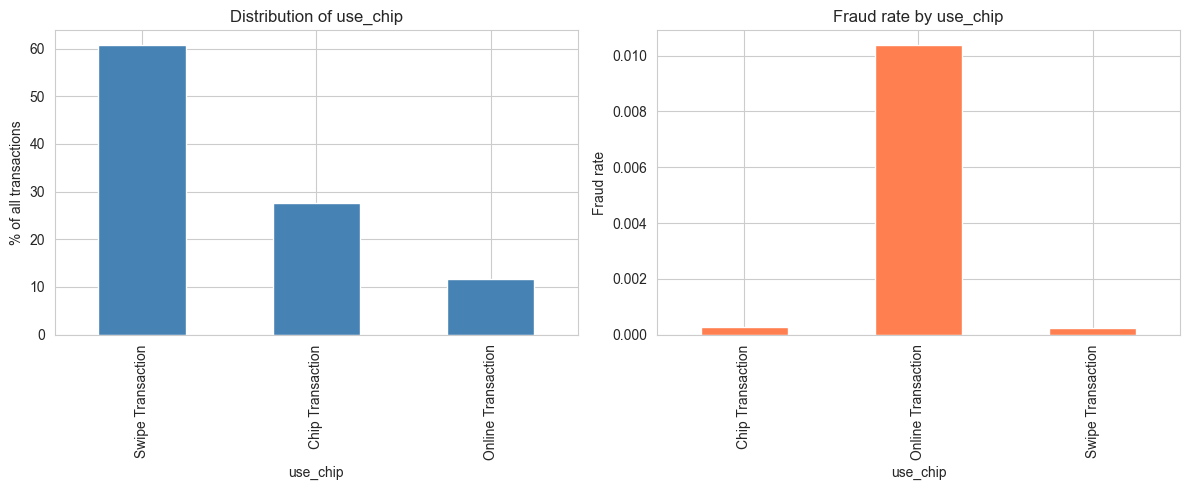

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

transactions_df['use_chip'].value_counts(normalize=True).mul(100).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of use_chip')
axes[0].set_ylabel('% of all transactions')

fraud_rate = transactions_df.groupby('use_chip')['target'].apply(lambda x: (x=='Yes').sum() / len(x))
fraud_rate.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Fraud rate by use_chip')
axes[1].set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

* online transactions have the lowest rate of transactions distributions, but have the highest fraud rate

### merchant_city vs target

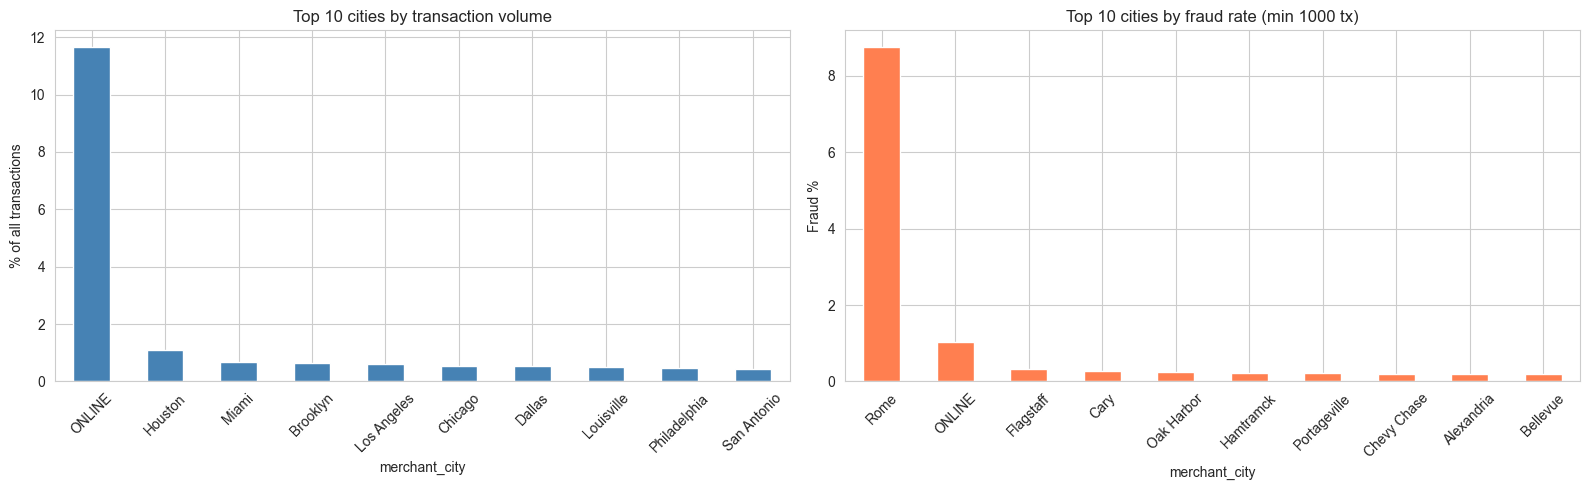

In [ ]:
top_cities = transactions_df['merchant_city'].value_counts(normalize=True).head(10).mul(100)

city_counts = transactions_df.groupby('merchant_city').size()
valid_cities = city_counts[city_counts >= 1000].index

fraud_by_city = transactions_df[transactions_df['merchant_city'].isin(valid_cities)].groupby('merchant_city')['target'].apply(lambda x: (x=='Yes').mean() * 100).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_cities.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 cities by transaction volume')
axes[0].set_ylabel('% of all transactions')
axes[0].tick_params(axis='x', rotation=45)

fraud_by_city.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 cities by fraud rate (min 1000 tx)')
axes[1].set_ylabel('Fraud %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* online transactions have the most transactions and around 1% of fraud and Rome has around 9% of fraud. 
* we can make is_online ariable and remove use_chip

### merchant_state vs target

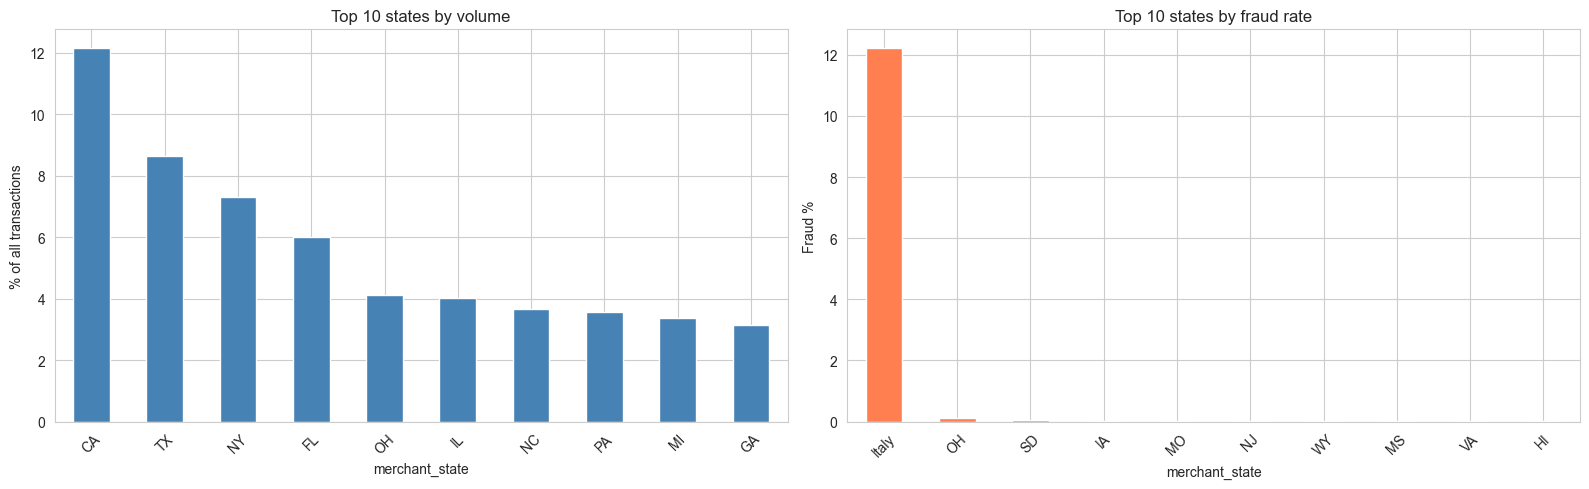

In [116]:
top_states = transactions_df['merchant_state'].value_counts(normalize=True).head(10).mul(100)

state_counts = transactions_df.groupby('merchant_state').size()
valid_states = state_counts[state_counts >= 500].index

fraud_by_state = transactions_df[transactions_df['merchant_state'].isin(valid_states)].groupby('merchant_state')['target'].apply(lambda x: (x=='Yes').mean() * 100).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_states.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 states by volume')
axes[0].set_ylabel('% of all transactions')
axes[0].tick_params(axis='x', rotation=45)

fraud_by_state.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 states by fraud rate')
axes[1].set_ylabel('Fraud %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* we will add is_international variable

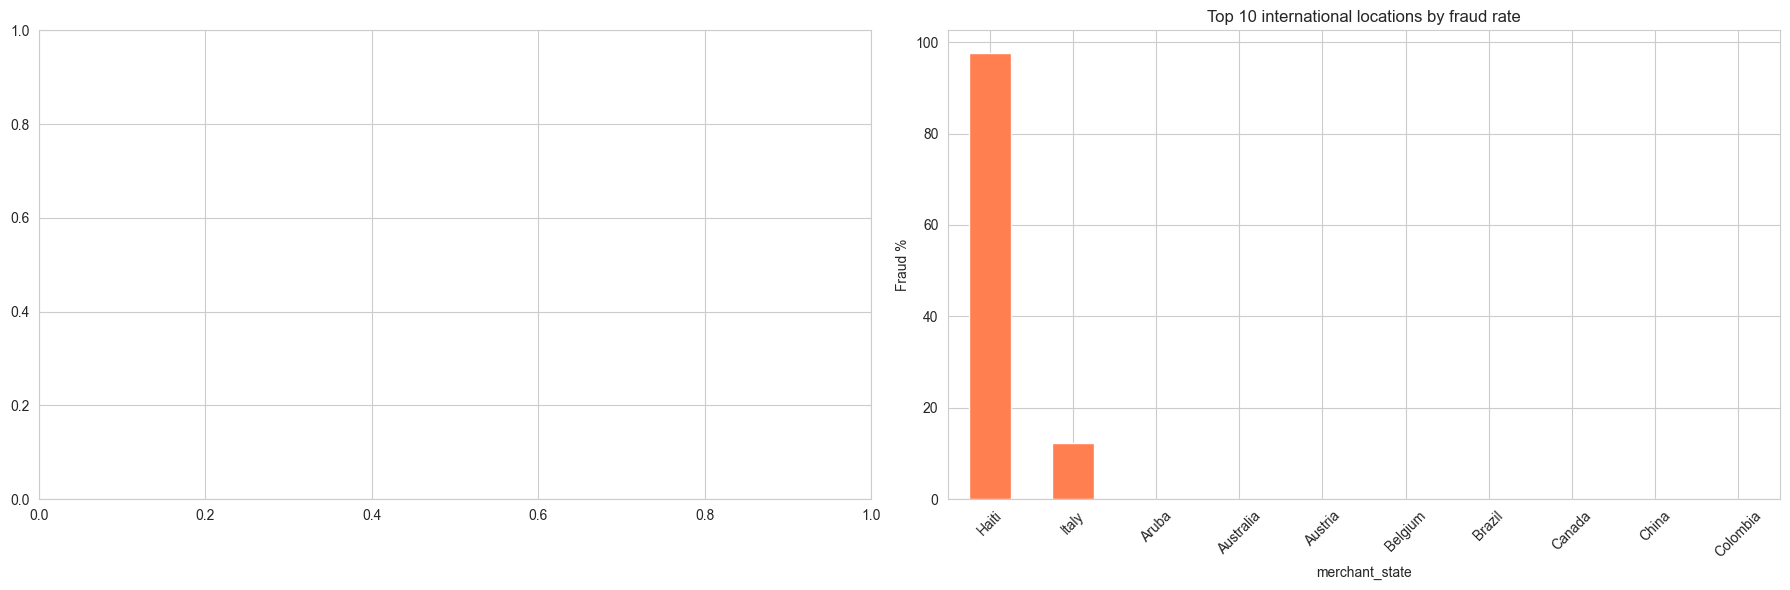

In [129]:
us_states = ['AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
             'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
             'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
             'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
             'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY','ONLINE']


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fraud_us = transactions_df[transactions_df['merchant_state'].isin(us_states)].groupby('merchant_state').agg(fraud_rate=('target', lambda x: (x=='Yes').mean() * 100),total=('target', 'count')).reset_index()
fraud_us = fraud_us[fraud_us['total'] >= 100]

fig_us = px.choropleth(
    fraud_us,
    locations='merchant_state',
    locationmode='USA-states',
    color='fraud_rate',
    scope='usa',
    title='Fraud rate by US state',
    color_continuous_scale='Reds'
)
fig_us.show()

intl = transactions_df[~transactions_df['merchant_state'].isin(us_states)]
fraud_intl = intl.groupby('merchant_state').agg(fraud_rate=('target', lambda x: (x=='Yes').mean() * 100),total=('target', 'count')).reset_index()
fraud_intl = fraud_intl[fraud_intl['total'] >= 100].nlargest(10, 'fraud_rate')

fraud_intl.plot(kind='bar', x='merchant_state', y='fraud_rate', color='coral', ax=axes[1], legend=False)
axes[1].set_title('Top 10 international locations by fraud rate')
axes[1].set_ylabel('Fraud %')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

* we will add is_international feature

In [139]:
intl[intl["merchant_state"]=="Haiti"]

print("Haiti")
for n in obj_cols:
    if n=="date":
        print(intl[intl["merchant_state"]=="Haiti"]["year"].value_counts(normalize=True))
    else:
         print(intl[intl["merchant_state"]=="Haiti"][n].value_counts(normalize=True))

print("\n\Italy")
for n in obj_cols:
    if n=="date":
        print(intl[intl["merchant_state"]=="Italy"]["year"].value_counts(normalize=True))
    else:
         print(intl[intl["merchant_state"]=="Italy"][n].value_counts(normalize=True))



Haiti
year
2010    0.969112
2012    0.023166
2011    0.007722
Name: proportion, dtype: float64
use_chip
Swipe Transaction    1.0
Name: proportion, dtype: float64
merchant_city
Port au Prince    1.0
Name: proportion, dtype: float64
merchant_state
Haiti    1.0
Name: proportion, dtype: float64
errors
Insufficient Balance    0.461538
Bad PIN                 0.307692
Technical Glitch        0.230769
Name: proportion, dtype: float64
target
Yes    0.976834
No     0.023166
Name: proportion, dtype: float64

\Italy
year
2014    0.234375
2017    0.204545
2016    0.197443
2013    0.127841
2012    0.071733
2011    0.068182
2010    0.051847
2015    0.044034
Name: proportion, dtype: float64
use_chip
Swipe Transaction    0.607955
Chip Transaction     0.392045
Name: proportion, dtype: float64
merchant_city
Rome    1.0
Name: proportion, dtype: float64
merchant_state
Italy    1.0
Name: proportion, dtype: float64
errors
Insufficient Balance    0.483871
Bad PIN                 0.419355
Technical Glitch    

Haiti has almost all of the transactions in 2010 and looks like a confound. To compare them, Italy was investigated and looks like error message is more informative rather than country itself

### errors vs target

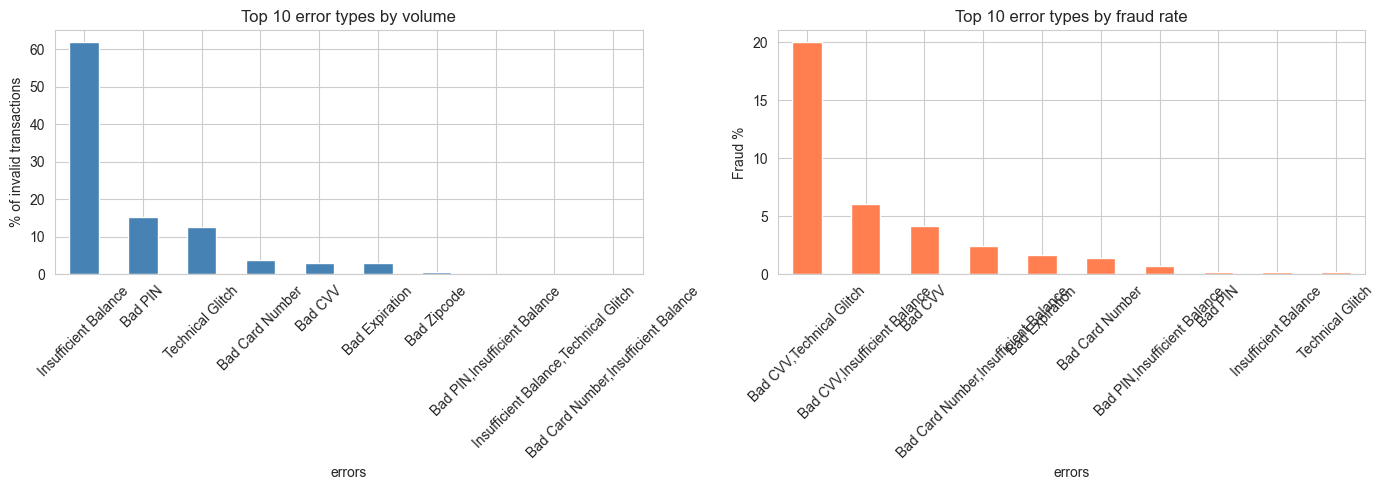

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

transactions_df['errors'].dropna().value_counts(normalize=True).head(10).mul(100).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 error types by volume')
axes[0].set_ylabel('% of invalid transactions')
axes[0].tick_params(axis='x', rotation=45)

fraud_by_error = transactions_df.copy()
fraud_by_error['errors'] = fraud_by_error['errors'].fillna('No Error')
fraud_by_error.groupby('errors')['target'].apply(lambda x: (x=='Yes').mean() * 100).nlargest(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 error types by fraud rate')
axes[1].set_ylabel('Fraud %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* Bad cvv has the highest fraud rate among all, so we can introduce 'has_bad_cvv' binary variable

### object cols and effect size on the target

In [126]:

def cramers_v(col):
    ct = pd.crosstab(transactions_df[col].fillna('No Error'), transactions_df['target'])
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in obj_cols:
    if col not in ["date", "target"]:
        print(f'{col}: {cramers_v(col):.4f}')

use_chip: 0.0857
merchant_city: 0.2170
merchant_state: 0.1838
errors: 0.0263


* merchant_city and merchant_state have the highest efect sizes

## Check multicolinearity

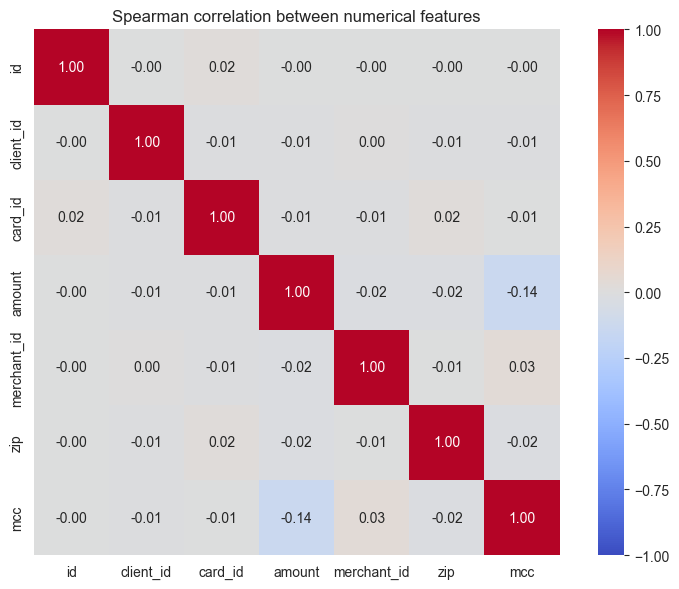

In [127]:

corr = transactions_df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,vmin=-1,vmax=1,square=True)
plt.title('Spearman correlation between numerical features')
plt.tight_layout()
plt.show()

no multicolinearity is detected